In [16]:
import numpy as np

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = self._step_function
        self.weights = None
        self.bias = None

    def _step_function(self, x):
        return np.where(x >= 0, 1, 0)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors_ = []
        for _ in range(self.n_iters):
            error_count = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_func(linear_output)
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
                error_count += int(update != 0.0)
            self.errors_.append(error_count)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_func(linear_output)

In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

X, y = make_classification(
n_samples = 1000,
n_features = 2,     # Solo dos caracteristicas
n_informative = 2,  # Ambas son informativas
n_redundant = 0,    # Ninguna redundante
n_repeated= 0,      # Ninguna repetida
n_classes = 2,
n_clusters_per_class=1,
random_state=42
)

In [33]:
y

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0])

In [40]:
p = Perceptron(learning_rate=0.01, n_iters=1000)
p.fit(X,y)

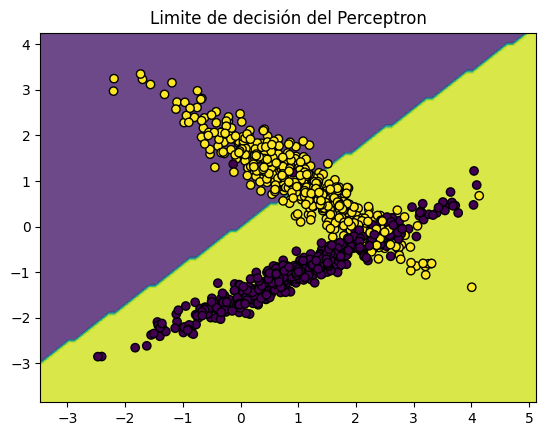

In [ ]:
# Visualizacion del limite de decisión

X_min, X_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(X_min, X_max, 0.1),np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = p.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title('Limite de decisión del Perceptron')
plt.show()

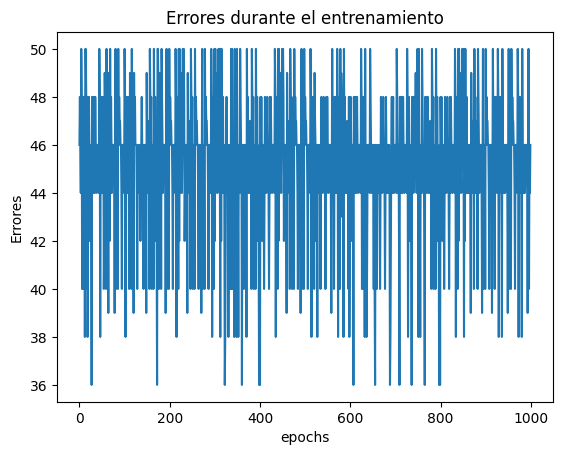

In [45]:
# Errores por epoch
plt.plot(range(len(p.errors_)), p.errors_)
plt.xlabel('epochs')
plt.ylabel('Errores')
plt.title('Errores durante el entrenamiento')
plt.show()

In [46]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
iris = load_iris()
X = iris.data[:100, [2, 3]]  # Solo dos características para visualización
y = iris.target[:100]         # Solo dos clases


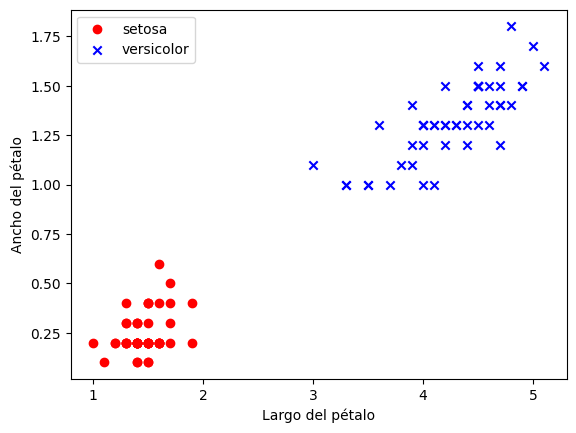

In [ ]:
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='setosa')
plt.scatter(X[50:, 0], X[50:, 1], color='blue', marker='x', label='versicolor')
plt.xlabel('Largo del pétalo')
plt.ylabel('Ancho del pétalo')
plt.legend(loc='upper left')
plt.show()